In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")


In [ ]:
# STEP 1: Load the dataset

df = pd.read_csv("weatherHistoryy.csv")

# Preview data
df.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51,Partly cloudy throughout the day.


In [ ]:
# STEP 2: Data Cleaning

# Remove missing values
df = df.dropna()

# Remove invalid pressure values (sensor errors)
df = df[df['Pressure (millibars)'] > 0]

# Drop redundant column if present
if 'Loud Cover' in df.columns:
    df = df.drop('Loud Cover', axis=1)

df.shape


(94648, 11)

In [ ]:
# STEP 3: Feature Engineering (Cyclical Time Encoding)

df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# Extract day of year
df['DayOfYear'] = df['Formatted Date'].dt.dayofyear

# Apply sine and cosine transformation to capture seasonality
df['day_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)

df[['DayOfYear', 'day_sin', 'day_cos']].head()


,DayOfYear,day_sin,day_cos
0,90,0.999745,0.022576
1,90,0.999745,0.022576
2,91,0.999986,0.005376
3,91,0.999986,0.005376
4,91,0.999986,0.005376


In [ ]:
# STEP 4: Define features (X) and target (y)

X = df[
    ['Humidity',
     'Pressure (millibars)',
     'Wind Speed (km/h)',
     'Visibility (km)',
     'day_sin',
     'day_cos']
]

y = df['Temperature (C)']


In [ ]:
# STEP 5: Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# STEP 6: Feature Scaling (Training Optimization)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# STEP 7: Polynomial Feature Expansion

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)


In [ ]:
# STEP 8: Train Optimized Model (Ridge Regression)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_poly, y_train)

# Predictions
y_pred = ridge_model.predict(X_test_poly)


In [ ]:
# STEP 9: Regression Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Optimized Regression Performance ---")
print(f"MAE: {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"R² Score: {r2:.2f}")


--- Optimized Regression Performance ---
MAE: 2.89 °C
RMSE: 3.66 °C
R² Score: 0.85


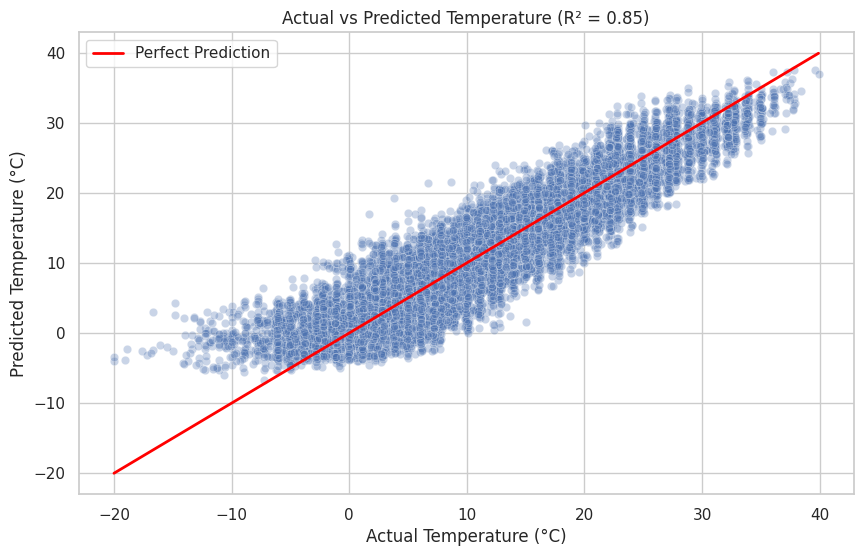

In [ ]:
# STEP 10: Visualization - Actual vs Predicted

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title(f'Actual vs Predicted Temperature (R² = {r2:.2f})')
plt.legend()
plt.show()


In [ ]:
# STEP 11: Improved Temperature Binning (Reduced Overlap)

def bin_temp(temp):
    if temp < 0:
        return 'Freezing'
    elif 0 <= temp < 10:
        return 'Cold'
    elif 10 <= temp < 20:
        return 'Mild'
    elif 20 <= temp < 30:
        return 'Warm'
    else:
        return 'Hot'

y_test_binned = [bin_temp(t) for t in y_test]
y_pred_binned = [bin_temp(t) for t in y_pred]


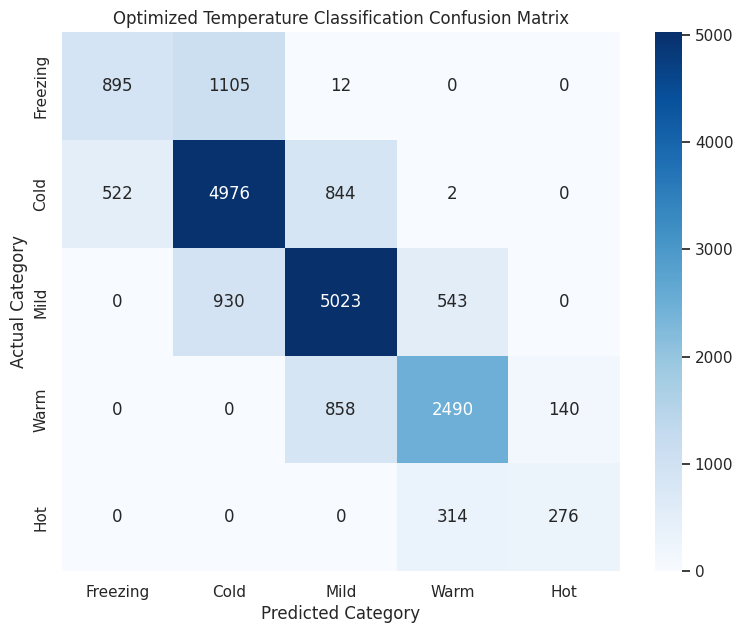

In [ ]:
# STEP 12: Confusion Matrix

labels = ['Freezing', 'Cold', 'Mild', 'Warm', 'Hot']
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Optimized Temperature Classification Confusion Matrix')
plt.show()


In [ ]:
# STEP 13: Classification Report

print("--- Optimized Classification Report ---")
print(classification_report(
    y_test_binned,
    y_pred_binned,
    target_names=labels
))


--- Optimized Classification Report ---
              precision    recall  f1-score   support

    Freezing       0.71      0.78      0.75      6344
        Cold       0.63      0.44      0.52      2012
        Mild       0.66      0.47      0.55       590
        Warm       0.75      0.77      0.76      6496
         Hot       0.74      0.71      0.73      3488

    accuracy                           0.72     18930
   macro avg       0.70      0.64      0.66     18930
weighted avg       0.72      0.72      0.72     18930

